# Airbnb Data Visualization and Descriptive Statistics Report

**Authors:**
- Arda Tutmaz (212134) — Part 1
- Pierre-Antoine Andries (212129) — Part 2
- Berkant Cora (212130) — Part 3

---
## 1. Project Introduction
This single Markdown file contains the data visualization case study for the Airbnb dataset. The objective is to practice data visualization using the `matplotlib` and `seaborn` libraries in Python to understand pricing, room types, and geographical distribution.

## 2. Loading the Dataset
To begin the analysis, we load the dataset directly from the raw GitHub link and inspect the first few rows.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
url = 'https://raw.githubusercontent.com/kflisikowsky/Descriptive_Statistics/refs/heads/main/data/airbnb.csv'
airbnb = pd.read_csv(url, index_col='Unnamed: 0')

# Minimal cleaning required for Part 1 visualizations
airbnb['price_num'] = pd.to_numeric(airbnb['price'].str.replace('$', '', regex=False), errors='coerce')
coords = airbnb['coordinates'].str.replace('[()]', '', regex=True).str.split(',', expand=True)
airbnb['latitude'] = pd.to_numeric(coords[0], errors='coerce')
airbnb['longitude'] = pd.to_numeric(coords[1], errors='coerce')

# Display the first 5 rows
print(airbnb.head())

   listing_id                                               name    host_id  \
0    13740704  Cozy,budget friendly, cable inc, private entra...   20583125   
1    22005115              Two floor apartment near Central Park   82746113   
2    21667615                  Beautiful 1BR in Brooklyn Heights      78251   
3     6425850                          Spacious, charming studio   32715865   
4    22986519              Bedroom on the lively Lower East Side  154262349   

  host_name          neighbourhood_full            coordinates  \
0    Michel         Brooklyn, Flatlands  (40.63222, -73.93398)   
1   Cecilia  Manhattan, Upper West Side  (40.78761, -73.96862)   
2    Leslie  Brooklyn, Brooklyn Heights   (40.7007, -73.99517)   
3    Yelena  Manhattan, Upper West Side  (40.79169, -73.97498)   
4    Brooke  Manhattan, Lower East Side  (40.71884, -73.98354)   

         room_type price  number_of_reviews last_review  reviews_per_month  \
0     Private room   45$                 10  2018-

## 3. Descriptive Statistics
Before visualizing, we check the summary statistics of the dataset to understand the central tendencies and distributions of numerical features like price.

In [2]:
# Summary statistics
print(airbnb.describe())

         listing_id       host_id  number_of_reviews  reviews_per_month  \
count  1.001900e+04  1.001900e+04       10019.000000        7944.000000   
mean   1.927634e+07  6.795923e+07          22.459727           1.353894   
std    1.095056e+07  7.863106e+07          43.173896           1.615380   
min    3.831000e+03  2.787000e+03           0.000000           0.010000   
25%    9.674772e+06  7.910880e+06           1.000000           0.200000   
50%    2.007030e+07  3.165167e+07           5.000000           0.710000   
75%    2.933864e+07  1.074344e+08          22.000000           2.000000   
max    3.648724e+07  2.741034e+08         510.000000          16.220000   

       availability_365       rating  number_of_stays      5_stars  \
count      10019.000000  7944.000000      7944.000000  7944.000000   
mean         112.284260     4.014458        33.991541     0.718599   
std          131.636043     0.575064        56.089279     0.079978   
min            0.000000     3.000633        

**Interpretation:** The descriptive statistics give us the mean, median, and max values, which indicate the presence of high-price outliers in our dataset.

## 4. Data Visualizations
### A. Price Distribution
We use a histogram to visualize how the prices of Airbnb listings are distributed.

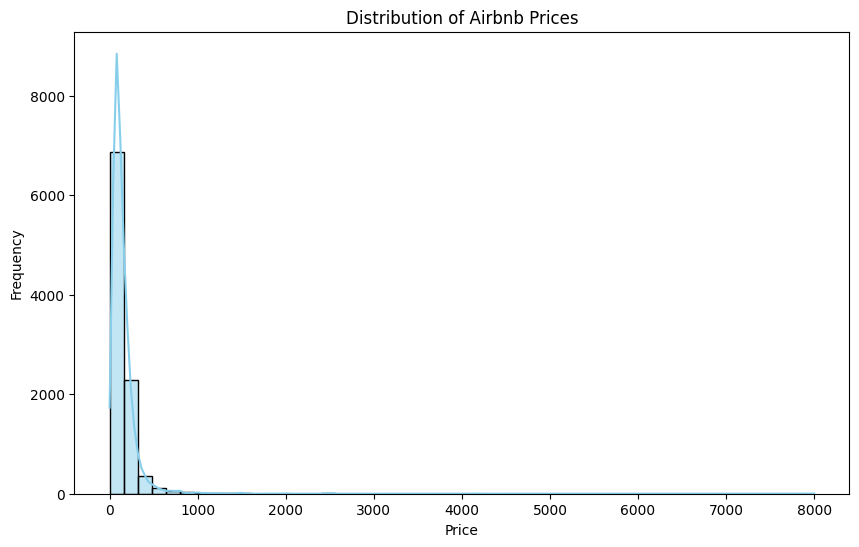

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(airbnb['price_num'].dropna(), bins=50, kde=True, color='skyblue')
plt.title('Distribution of Airbnb Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

**Insight:** The distribution is highly right-skewed, meaning the vast majority of listings are clustered at lower price points, with a few luxury properties pulling the average up.

### B. Room Type Popularity
A count plot helps us understand the market supply by showing the frequency of each room type.

C:\Users\BERKANT\AppData\Local\Temp\ipykernel_321784\304595188.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=airbnb, x='room_type', palette='viridis')


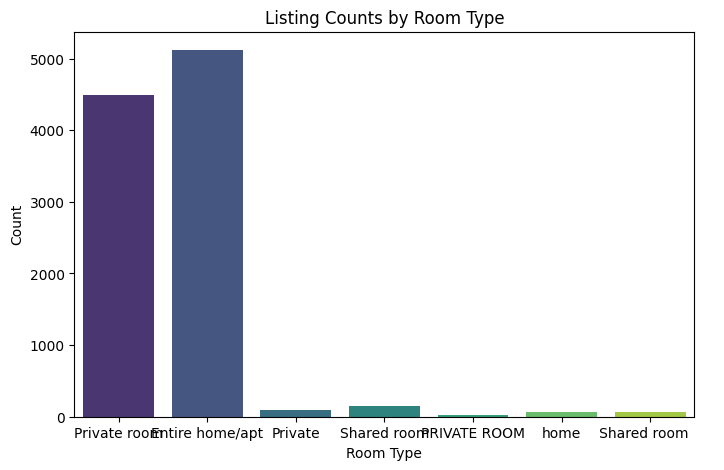

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(data=airbnb, x='room_type', palette='viridis')
plt.title('Listing Counts by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

**Insight:** This visualization reveals whether "Entire homes/apt" or "Private rooms" are more common in this specific Airbnb market.

### C. Geographical Price Distribution
By plotting the latitude and longitude, we can map the listings. Adding price as the hue shows us the most expensive neighborhoods.

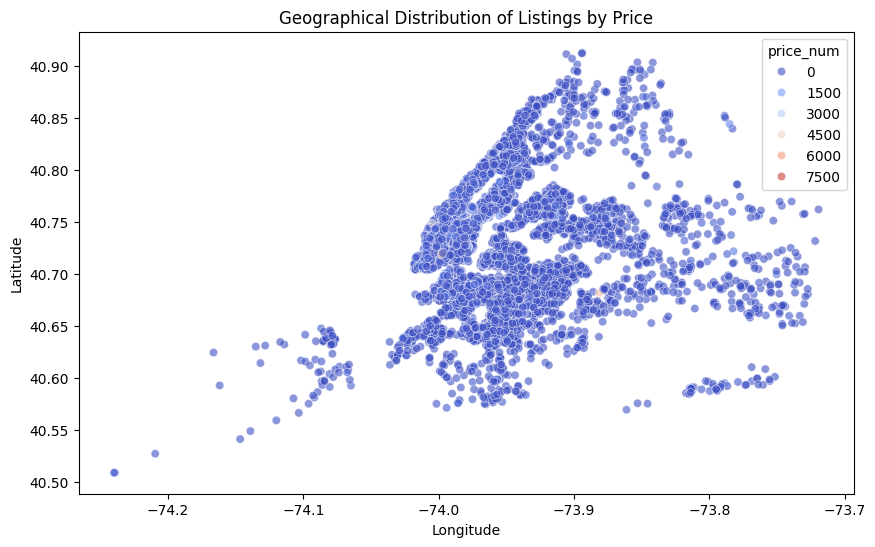

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=airbnb, x='longitude', y='latitude', hue='price_num', palette='coolwarm', alpha=0.6)
plt.title('Geographical Distribution of Listings by Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

**Insight:** Prices are not evenly distributed; certain geographic clusters command much higher prices, likely indicating city centers or popular tourist areas.

---

## Part 2: Additional Analyses 

The Part 1 visualizations look at price overall, room-type frequency, and geography in isolation. Part 2 adds two analyses that address descriptive-statistics concepts not yet covered in the report: **how the price distribution varies *across* room types** (central tendency and dispersion within categories), and **how the numerical features relate to one another** (multivariate correlation).

### Data Preparation for Part 2
Two short cleanups are needed before the analyses below can run on the raw dataset:

In [6]:
# Price is stored as a string with a "$" suffix (e.g. "45$") -> cast to float
airbnb['price_num'] = airbnb['price'].str.replace('$', '', regex=False).astype(float)

# Room type has trailing whitespace and case variants (e.g. "PRIVATE ROOM",
# "   Shared room") that split otherwise-identical categories. Normalize.
airbnb['room_type'] = airbnb['room_type'].str.strip().str.title()

**Note:** After normalization, two small residue categories remain (`Private` with 89 listings, `Home` with 66 listings). They are kept in the analyses below as a transparent record of the underlying data quality, but the bulk of the ~9,950 listings sit in the three canonical categories `Entire Home/Apt`, `Private Room`, and `Shared Room`.

### D. Price Distribution by Room Type
A box plot per room type makes the per-category median, IQR, whiskers, and outliers visible in a single figure.

C:\Users\BERKANT\AppData\Local\Temp\ipykernel_321784\3302983830.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=airbnb, x='room_type', y='price_num', palette='viridis')


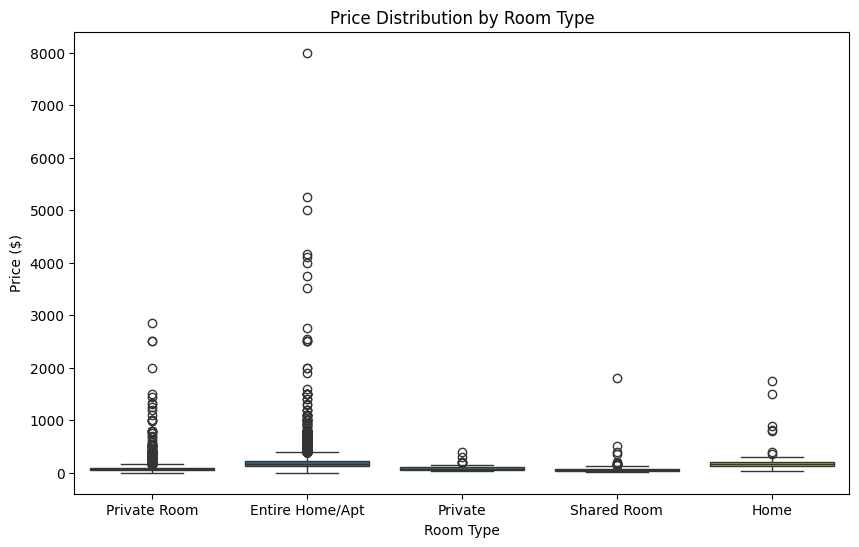

                    n    mean  median     std      q1     q3     iqr
room_type                                                           
Entire Home/Apt  5021  209.28   163.0  250.66  120.00  230.0  110.00
Home               65  243.66   170.0  294.00  125.00  211.0   86.00
Private            86   86.30    75.0   55.50   50.00  100.0   50.00
Private Room     4390   88.05    70.0  109.78   51.25   95.0   43.75
Shared Room       219   70.41    50.0  129.25   34.50   75.0   40.50


In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=airbnb, x='room_type', y='price_num', palette='viridis')
plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.show()

summary = airbnb.groupby('room_type')['price_num'].agg(
    n='count', mean='mean', median='median', std='std',
    q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75)
)
summary['iqr'] = summary['q3'] - summary['q1']
print(summary.round(2))

**Insight:** `Entire Home/Apt` has by far the highest central tendency and the widest dispersion.

### E. Correlation Matrix of Numerical Features
A correlation heatmap brings all numerical features into one view.

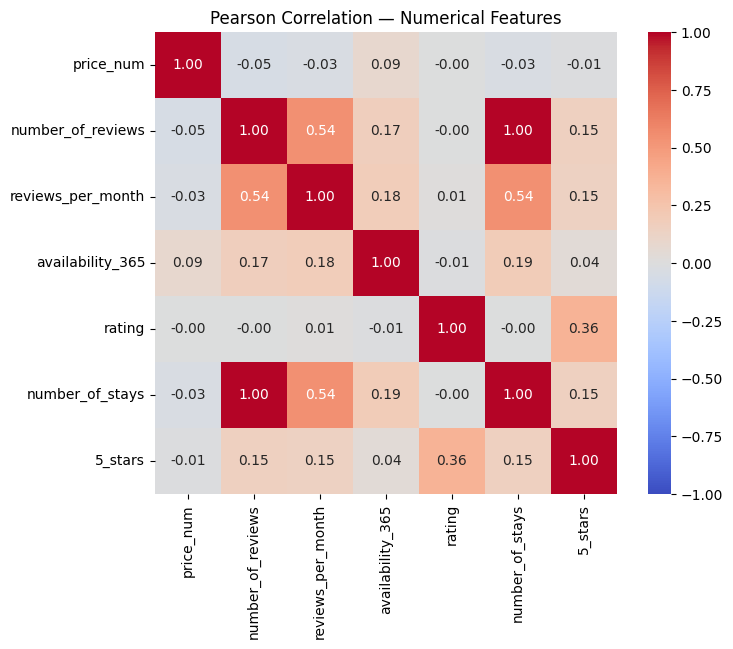

In [8]:
num_cols = ['price_num', 'number_of_reviews', 'reviews_per_month',
            'availability_365', 'rating', 'number_of_stays', '5_stars']
corr = airbnb[num_cols].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True)
plt.title('Pearson Correlation — Numerical Features')
plt.show()

**Conclusion of Part 2**
Part 1 establishes the marginal distributions of price, room type, and geography. Part 2 sharpens the picture by showing that price distributions differ substantially **between** room types. 

---

## Part 3: Additional Analyses 
### F. Borough and Neighbourhood Price Ranking

Median price by borough:
borough
Manhattan        150.0
Brooklyn          90.0
Staten Island     75.0
Queens            72.0
Bronx             65.0
Name: price_num, dtype: float64


C:\Users\BERKANT\AppData\Local\Temp\ipykernel_321784\2664871496.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=borough_price.values, y=borough_price.index, palette='mako')


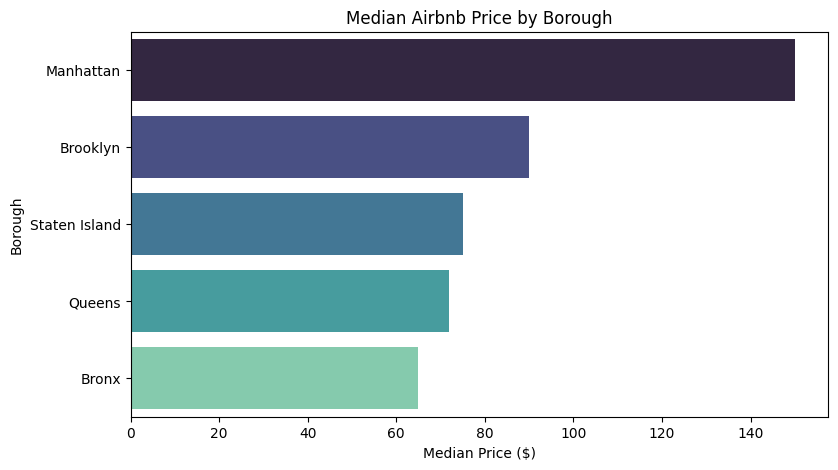

In [9]:
# Split neighbourhood_full into borough and neighbourhood
loc_parts = airbnb['neighbourhood_full'].str.split(',', n=1, expand=True)
airbnb['borough'] = loc_parts[0].str.strip()
airbnb['neighbourhood'] = loc_parts[1].str.strip()

# Borough-level median price
borough_price = (
    airbnb.groupby('borough')['price_num']
    .median()
    .sort_values(ascending=False)
)
print('Median price by borough:')
print(borough_price)

plt.figure(figsize=(9, 5))
sns.barplot(x=borough_price.values, y=borough_price.index, palette='mako')
plt.title('Median Airbnb Price by Borough')
plt.xlabel('Median Price ($)')
plt.ylabel('Borough')
plt.show()

### G. Availability and Price Relationship

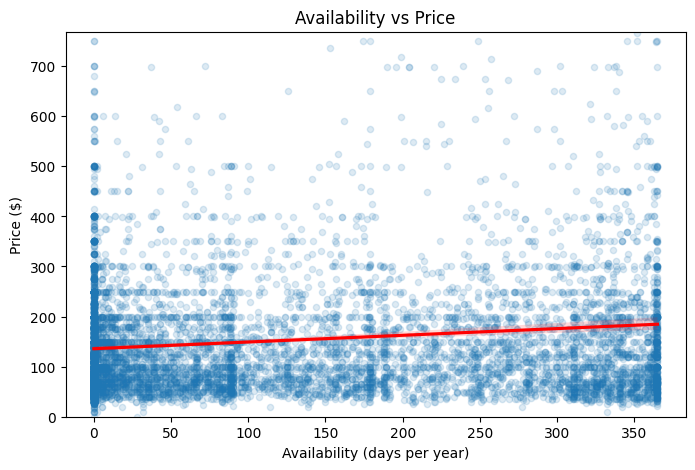

In [10]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=airbnb,
    x='availability_365',
    y='price_num',
    scatter_kws={'alpha': 0.15, 's': 20},
    line_kws={'color': 'red'}
)
plt.title('Availability vs Price')
plt.xlabel('Availability (days per year)')
plt.ylabel('Price ($)')
plt.ylim(0, airbnb['price_num'].quantile(0.99))
plt.show()

### H. Outlier-Robust Price Comparison by Room Type

In [11]:
# Baseline medians
baseline = airbnb.groupby('room_type')['price_num'].median().rename('baseline_median')

# Trim upper 1% outliers
cap = airbnb['price_num'].quantile(0.99)
trimmed = airbnb[airbnb['price_num'] <= cap]
trimmed_median = trimmed.groupby('room_type')['price_num'].median().rename('trimmed_median')

robust_check = pd.concat([baseline, trimmed_median], axis=1)
robust_check['difference'] = robust_check['baseline_median'] - robust_check['trimmed_median']
print(robust_check.sort_values('baseline_median', ascending=False))

                 baseline_median  trimmed_median  difference
room_type                                                   
Home                       170.0           150.0        20.0
Entire Home/Apt            163.0           160.0         3.0
Private                     75.0            75.0         0.0
Private Room                70.0            70.0         0.0
Shared Room                 50.0            49.5         0.5


**Conclusion:** The core room-type price hierarchy is robust even when extreme values are reduced.